In [3]:
import pandas as pd

skani_results = pd.read_csv("../../output/simulated_data_wrong_reference/Ecoli_ANI_values.tsv", sep="\t")

In [2]:
skani_results.head()

,Ref_file,Query_file,ANI,Align_fraction_ref,Align_fraction_query,Ref_name,Query_name
0,./data/reference/Ecoli/GCF_018512185.1.fna,./data/reference/Ecoli_K12_MG1655.fasta,99.99,90.95,99.68,NZ_JAFFIC010000003.1 Escherichia coli strain J...,NC_000913.3 Escherichia coli str. K-12 substr....
1,./data/reference/Ecoli/GCF_002458255.1.fna,./data/reference/Ecoli_K12_MG1655.fasta,99.99,96.67,97.69,NZ_NJTR01000100.1 Escherichia coli strain MOD1...,NC_000913.3 Escherichia coli str. K-12 substr....
2,./data/reference/Ecoli/GCF_021547135.1.fna,./data/reference/Ecoli_K12_MG1655.fasta,99.72,90.65,93.53,NZ_JAKFSJ010000100.1 Escherichia coli strain 5...,NC_000913.3 Escherichia coli str. K-12 substr....
3,./data/reference/Ecoli/GCA_900195655.1.fna,./data/reference/Ecoli_K12_MG1655.fasta,99.62,85.13,91.51,FZGG01000553.1 Escherichia coli isolate F1_402...,NC_000913.3 Escherichia coli str. K-12 substr....
4,./data/reference/Ecoli/GCF_016785425.1.fna,./data/reference/Ecoli_K12_MG1655.fasta,99.55,85.14,92.72,NZ_JADBFA010000100.1 Escherichia coli strain B...,NC_000913.3 Escherichia coli str. K-12 substr....


In [4]:
ani_values = []
af_values = []
read_identity_values = []


for i in range(len(skani_results)):
    # Get reference info from skani results
    ref = skani_results.iloc[i]["Ref_file"]
    ref_accession = ref.split("/")[-1].split(".fna")[0]
    ani = skani_results.iloc[i]["ANI"]
    af = skani_results.iloc[i]["Align_fraction_ref"]

    # Get read identity from the corresponding mapping results
    mapping_results = pd.read_csv(f"../../output/simulated_data_wrong_reference/{ref_accession}.summary_identity_stats.csv")
    read_identity = mapping_results["identity"].item()

    ani_values.append(ani)
    af_values.append(af)
    read_identity_values.append(read_identity)

Text(0.5, 1.0, 'Read Identity vs ANI')

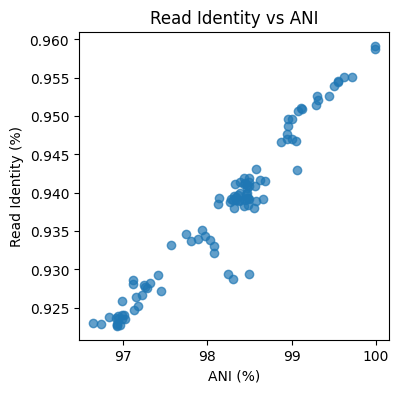

In [11]:
# Plot a scatter plot of Read Identity vs ANI

import matplotlib.pyplot as plt
plt.figure(figsize=(4, 4))
plt.scatter(ani_values, read_identity_values, alpha=0.7)
plt.ylabel("Read Identity (%)")
plt.xlabel("ANI (%)")
plt.title("Read Identity vs ANI")